In [6]:
import pandas as pd

# Cargar el archivo en un DataFrame
df = pd.read_csv("Tabulacion.csv", delimiter=";")

# Mostrar las primeras filas para inspeccionar los datos
df.head()

,Marca temporal,Pregunta 1,Pregunta 2,Pregunta 3,Pregunta 4,Pregunta 5,Pregunta 6,Pregunta 7,Pregunta 8
0,15/1/2025 17:50,1.0,3.0,4.0,2.0,4.0,2.0,3.0,4.0
1,15/1/2025 17:53,2.0,1.0,3.0,4.0,4.0,4.0,4.0,0.0
2,15/1/2025 17:54,1.0,3.0,3.0,4.0,4.0,5.0,4.0,3.0
3,15/1/2025 17:55,1.0,2.0,2.0,4.0,5.0,5.0,4.0,4.0
4,15/1/2025 17:56,1.0,3.0,3.0,5.0,5.0,5.0,4.0,4.0


In [7]:
# Eliminar la columna de marca temporal
df_clean = df.drop(columns=["Marca temporal"])

# Verificar valores nulos
missing_values = df_clean.isnull().sum()

# Obtener estadísticas descriptivas básicas
data_summary = df_clean.describe()

missing_values, data_summary

(Pregunta 1    1
 Pregunta 2    1
 Pregunta 3    1
 Pregunta 4    1
 Pregunta 5    1
 Pregunta 6    1
 Pregunta 7    1
 Pregunta 8    1
 dtype: int64,
        Pregunta 1  Pregunta 2  Pregunta 3  Pregunta 4  Pregunta 5  Pregunta 6  \
 count   48.000000   48.000000   48.000000   48.000000   48.000000   48.000000   
 mean     2.354167    2.541667    2.708333    3.125000    3.041667    3.687500   
 std      1.312616    1.110076    1.398454    1.423586    1.367687    1.094595   
 min      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
 25%      1.000000    2.000000    2.000000    2.000000    2.000000    3.000000   
 50%      2.000000    2.500000    2.500000    3.000000    3.000000    4.000000   
 75%      3.000000    3.000000    4.000000    4.000000    4.000000    5.000000   
 max      6.000000    5.000000    7.000000    6.000000    5.000000    5.000000   
 
        Pregunta 7  Pregunta 8  
 count   48.000000   48.000000  
 mean     3.166667    3.333333  
 std      

In [8]:
# Rellenar valores nulos con la mediana de cada columna
df_clean = df_clean.fillna(df_clean.median())

# Verificar si aún hay valores nulos
missing_values_after = df_clean.isnull().sum()

missing_values_after

Pregunta 1    0
Pregunta 2    0
Pregunta 3    0
Pregunta 4    0
Pregunta 5    0
Pregunta 6    0
Pregunta 7    0
Pregunta 8    0
dtype: int64

In [9]:
# Calcular la matriz de correlación
correlation_matrix = df_clean.corr()

# Obtener la correlación absoluta promedio de cada columna con las demás
correlation_mean = correlation_matrix.abs().mean().sort_values(ascending=False)

# Mostrar la variable con mayor correlación promedio (potencial variable objetivo)
correlation_mean


Pregunta 1    0.301074
Pregunta 7    0.273048
Pregunta 2    0.253013
Pregunta 5    0.250495
Pregunta 6    0.240969
Pregunta 3    0.237018
Pregunta 4    0.232017
Pregunta 8    0.175050
dtype: float64

In [ ]:
# Importar librerías necesarias para Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Definir variables predictoras (X) y variable objetivo (y)
X = df_clean.drop(columns=["Pregunta 1"])
y = df_clean["Pregunta 1"]

# Dividir en conjunto de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Inicializar y entrenar el modelo Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Calcular métricas de desempeño
report = classification_report(y_test, y_pred, output_dict=True)

# Convertir el reporte en DataFrame para visualizarlo mejor
report_df = pd.DataFrame(report).transpose()
report_df



C:\Users\mariy\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mariy\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mariy\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
1.0,0.666667,0.400000,0.500000,5.0
2.0,1.000000,0.333333,0.500000,6.0
3.0,0.250000,0.666667,0.363636,3.0
4.0,0.000000,0.000000,0.000000,1.0
5.0,0.000000,0.000000,0.000000,0.0
accuracy,0.400000,0.400000,0.400000,0.4
macro avg,0.383333,0.280000,0.272727,15.0
weighted avg,0.672222,0.400000,0.439394,15.0


<Figure size 1200x600 with 0 Axes>

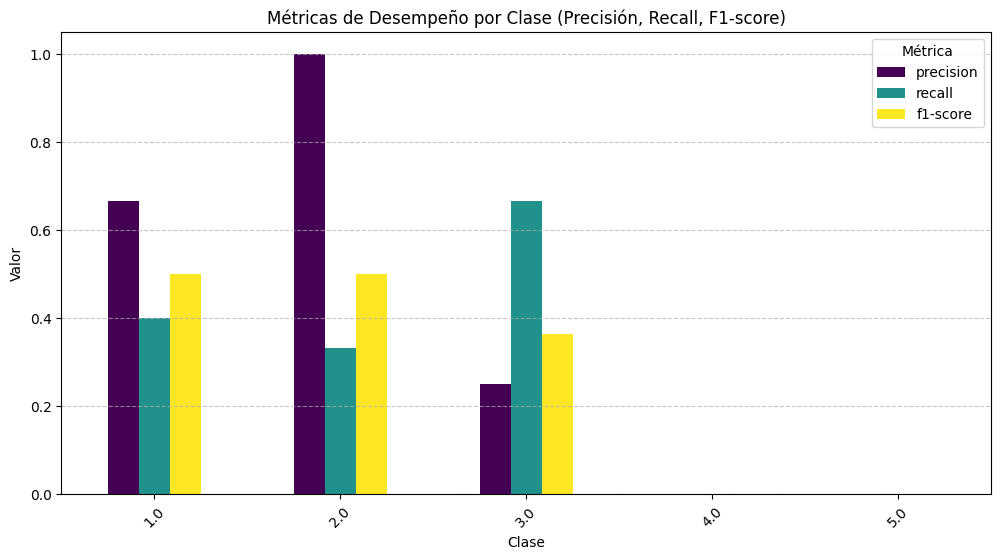

In [16]:
import matplotlib.pyplot as plt
# Eliminar filas de métricas generales para enfocarnos en las clases
report_df = report_df.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")

# Graficar métricas por clase
plt.figure(figsize=(12, 6))
report_df[["precision", "recall", "f1-score"]].plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.title("Métricas de Desempeño por Clase (Precisión, Recall, F1-score)")
plt.xlabel("Clase")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.legend(title="Métrica")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()